# GBP4 Network Evaluation

### Functions

In [1]:

### Perform GO enrichment
#BiocManager::install("fgsea", version="3.20")
annotate_module_GO <- function(genes, universe) {
  
  message(length(genes))
  message(length(universe))
  
  eg <- AnnotationDbi::mapIds(
    org.Hs.eg.db::org.Hs.eg.db,
    keys = genes,
    keytype = "SYMBOL",
    column = "ENTREZID",
    multiVals = "first"
  )
  eg <- na.omit(eg)
  
  universe_eg <- AnnotationDbi::mapIds(
    org.Hs.eg.db::org.Hs.eg.db,
    keys = universe,
    keytype = "SYMBOL",
    column = "ENTREZID",
    multiVals = "first"
  )
  universe_eg <- na.omit(universe_eg)
  
  clusterProfiler::enrichGO(
    gene = eg,
    universe = universe_eg,
    OrgDb = org.Hs.eg.db::org.Hs.eg.db,
    ont = "BP",
    pAdjustMethod = "BH",
    readable = TRUE
  )
}



## 0. Read in TOM files 
Read in the bulk TOM files that include GBP4.

In [ ]:
# read in the nodes and edges
library(data.table)

post_tom = readRDS("../results/gene_networks/TOM_filt2_POST.tsv")
dim(post_tom)
rownames(post_tom)
post_tom[1:2,]
# filter so above 0.1
post_tom <- as.data.frame(t(post_tom))
post_tom[1:2,]
post_tom_gbp <- post_tom[post_tom$GBP4 > 0.1,]
dim(post_tom_gbp)


pre_tom = readRDS("../results/gene_networks/TOM_filt2_PRE.tsv")
dim(pre_tom)
rownames(pre_tom)
pre_tom[1:2,]
# filter so above 0.1
pre_tom <- as.data.frame(t(pre_tom))
pre_tom[1:2,]
pre_tom_gbp <- pre_tom[pre_tom$GBP4 > 0.1,]
dim(pre_tom_gbp)

Warning message:
"package 'data.table' was built under R version 4.4.1"


[1]    16 17790

[1] "IDO1"    "CD40"    "JAK2"    "CTSS"    "ALDOC"   "ENO1"    "EGR1"   
 [8] "OAS3"    "RRM2"    "GBP4"    "AMOTL2"  "DDX11"   "GPR173"  "CDKL2"  
[15] "SHROOM1" "CD274"

,A1BG,A1CF,A2M,A2M-AS1,A4GALT,AA06,AACSP1,AADAC,AADAT,AAGAB,...,ZSWIM5,ZSWIM7,ZUP1,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZYG11A,ZZZ3
IDO1,0.003444847,0.014433708,0.07669309,0.09104672,0.016678222,0.004008833,0.001989215,0.005795535,0.00399705,0.02900853,...,0.032479291,0.001393581,0.02591058,0.01572633,0.02546004,0.02123813,0.0007477157,0.005647243,0.01241453,0.002826147
CD40,0.005085060,0.002224599,0.12629414,0.12547487,0.005665729,0.002933830,0.012978508,0.005570941,0.00208472,0.03393929,...,0.003038772,0.018418153,0.01884811,0.04238998,0.04175595,0.04052812,0.0423766343,0.018746086,0.02047478,0.029535809


,IDO1,CD40,JAK2,CTSS,ALDOC,ENO1,EGR1,OAS3,RRM2,GBP4,AMOTL2,DDX11,GPR173,CDKL2,SHROOM1,CD274
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0.003444847,0.005085060,0.005522494,0.011314194,0.01770066,0.006835278,0.01227732,0.0065025515,0.01684868,0.0006527797,0.0005027431,0.025110823,0.002188618,0.018475432,0.018831825,0.01363254
A1CF,0.014433708,0.002224599,0.000158338,0.005503568,0.02467449,0.009145150,0.00830774,0.0001654522,0.05157090,0.0024262296,0.0525194274,0.006339242,0.002609886,0.006684623,0.001435064,0.01633675


...

[1]    14 17800

[1] "IDO1"   "CD40"   "JAK2"   "CTSS"   "TMUB2"  "OAS3"   "RRM2"   "GBP4"  
 [9] "AMOTL2" "HCN3"   "DDX11"  "GPR173" "CDKL2"  "CD274"

,A1BG,A1CF,A2M,A2M-AS1,A2ML1,A4GALT,AACS,AADAC,AADACL2-AS1,AADACL3,...,ZSWIM4,ZSWIM5,ZSWIM7,ZUP1,ZW10,ZXDA,ZXDB,ZXDC,ZYG11A,ZZZ3
IDO1,0.06626566,0.010284358,0.04945232,0.08467907,0.01851006,0.039549819,0.04274572,0.013776879,0.021675020,0.008634891,...,0.031575529,0.026383750,0.023849914,0.03287907,0.004843114,0.007217507,0.002747536,0.04923758,0.007491404,0.02941588
CD40,0.01368792,0.004463232,0.11664637,0.11795588,0.00880173,0.002603325,0.02065402,0.003615359,0.004788548,0.010259432,...,0.009129959,0.004378935,0.008017305,0.01454242,0.039528854,0.006771159,0.009091861,0.01801644,0.024239210,0.01452212


,IDO1,CD40,JAK2,CTSS,TMUB2,OAS3,RRM2,GBP4,AMOTL2,HCN3,DDX11,GPR173,CDKL2,CD274
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0.06626566,0.013687922,0.04988825,0.04167987,0.084281246,0.003125084,0.03991126,0.04493128,0.115537337,0.1003458,0.11838517,0.080173512,0.06891672,0.048260001
A1CF,0.01028436,0.004463232,0.01014966,0.02504834,0.009459083,0.004136255,0.01222999,0.01846503,0.004789314,0.0170637,0.04321907,0.005448719,0.01066745,0.001639509


[1] 738  14

## Split Genes based on Pre, Post, Shared
Consider whether genes are connected to GBP4 regardless of timepoint, or particularly in one time point.

\> 0.1 tends to indicate a nonrandom connection between genes 

We also did not consider lncRNAs for simplicity of interpretation

### Using Basic comparison
Higher than 0.1 in Pre or post, but not the other. 

In [3]:
# only get those above 0.1 in one and not found at all in the other
post_only_strict = setdiff(rownames(post_tom[post_tom$GBP4 > 0.10,]), rownames(pre_tom_gbp))
post_only_strict = setdiff(rownames(post_tom_gbp), rownames(pre_tom_gbp))
post_only_strict = post_only_strict[!grepl("^LOC1|^LINC]", post_only_strict)]
pre_only_strict = setdiff(rownames(pre_tom[pre_tom$GBP4 > 0.10,]), rownames(post_tom_gbp))
# remove any LOC or LIN 
pre_only_strict = pre_only_strict[!grepl("^LOC1|^LINC]", pre_only_strict)]
shared_strict = intersect(rownames(pre_tom[pre_tom$GBP4 > 0.10,]), rownames(post_tom[post_tom$GBP4 > 0.10,]))
shared_strict = shared_strict[!grepl("^LOC1|^LINC", shared_strict)]

length(post_only_strict)
post_only_strict
length(pre_only_strict)
pre_only_strict[1:200]
pre_only_strict[201:508]
length(shared_strict)
shared_strict

[1] 51

[1] "AQP1"     "BATF"     "C16orf54" "CALCRL"   "CD209"    "CD8B"    
 [7] "CLEC10A"  "CLEC1A"   "CXCR3"    "DOK2"     "EMCN"     "FAM78A"  
[13] "FOLR2"    "GFI1"     "GRK3"     "HCST"     "HLA-DOA"  "IGHG1"   
[19] "IGHG3"    "IGHG4"    "IGHGP"    "IGHV1-18" "IGHV3-11" "IGHV4-39"
[25] "IGKJ2"    "IGKJ3"    "IGKJ4"    "IGKV2-30" "IGLJ2"    "IGLV1-40"
[31] "IGLV2-11" "IGLV3-1"  "IGLV3-21" "LILRB5"   "LSP1"     "NAPSB"   
[37] "NFAM1"    "PPP1R16B" "PRR33"    "RAB37"    "SESN1"    "SFMBT2"  
[43] "SHE"      "SIT1"     "SMAP2"    "SPN"      "TBX21"    "TMC8"    
[49] "TRAF1"    "ZAP70"    "ZNF366"

[1] 508

[1] "ABCA1"        "ABHD8"        "ACOT7"        "ACSL1"        "ACSL5"       
  [6] "ADAMDEC1"     "ADGRE1"       "ADGRE2"       "ADORA3"       "ALKBH4"      
 [11] "ALOX5AP"      "ANAPC11"      "ANKRD22"      "ANTXR2"       "AP4M1"       
 [16] "APBB1IP"      "APOBEC3G"     "APOC2"        "APOC4-APOC2"  "APOL1"       
 [21] "APOL2"        "APOL3"        "APOL4"        "APOL6"        "AQP9"        
 [26] "ARHGAP18"     "ARHGAP25"     "ARL11"        "ASAH1"        "ATAD3A"      
 [31] "ATP6V1B2"     "ATP8B4"       "AURKAIP1"     "B2M"          "BATF2"       
 [36] "BCL2A1"       "BMP2K"        "BTN3A1"       "BTN3A3"       "C1QB"        
 [41] "C1S"          "C1orf159"     "C1orf162"     "C1orf35"      "C2"          
 [46] "C5orf58"      "CALHM6"       "CALHM6-AS1"   "CARD16"       "CARD6"       
 [51] "CASP1"        "CASP4"        "CASP5"        "CBX8"         "CCHCR1"      
 [56] "CCL3"         "CCL4"         "CCL4L2"       "CCL8"         "CCR3"        
 [61] "CCR6"         "CCR8"         "CCRL2"        "CD163"        "CD180"       
 [66] "CD274"        "CD300E"       "CD300LF"      "CD36"         "CD38"        
 [71] "CD3E"         "CD40"         "CD44"         "CD44-AS1"     "CD69"        
 [76] "CD80"         "CDT1"         "CELF2"        "CFH"          "CFLAR"       
 [81] "CHTF18"       "CLEC12A"      "CLEC12B"      "CLEC2B"       "CLEC4A"      
 [86] "CLEC4C"       "CLEC4D"       "CLEC5A"       "CLEC6A"       "CLEC9A"      
 [91] "CLECL1P"      "CLIC2"        "CLNK"         "CMPK2"        "CNDP2"       
 [96] "CPNE8"        "CPSF4"        "CR1"          "CSF1R"        "CTSH"        
[101] "CTSL"         "CTSO"         "CXCL10"       "CXCL11"       "CXCL13"      
[106] "CXCL9"        "CYLD"         "CYP7B1"       "CYRIA"        "CYSLTR2"     
[111] "DAB2"         "DDX60L"       "DNAJC5B"      "DPYD"         "DTHD1"       
[116] "DTX3L"        "DVL1"         "ELK3"         "ELL2"         "EPSTI1"      
[121] "ERAP1"        "ETS1"         "F13A1"        "FAM20A"       "FANCE"       
[126] "FAS"          "FBXL5"        "FCAR"         "FCER1G"       "FCGR1CP"     
[131] "FCGR2A"       "FCGR3A"       "FCGR3B"       "FCRL1"        "FCRL2"       
[136] "FCRL3"        "FCRL4"        "FCRL5"        "FCRL6"        "FFAR4"       
[141] "FOXN3"        "FPR1"         "FYB1"         "GALC"         "GASK1B"      
[146] "GBP1"         "GBP1P1"       "GBP2"         "GIMAP6"       "GLIPR1"      
[151] "GLRX"         "GNG2"         "GNLY"         "GPNMB"        "GPR141"      
[156] "GPR183"       "GTDC1"        "GTPBP3"       "H1-10"        "H2AC12"      
[161] "H2AC13"       "H2AC25"       "H2AX"         "H2BC12"       "H2BC13"      
[166] "H2BC17"       "H3C13"        "H3C15"        "H4C11"        "HACD4"       
[171] "HCLS1"        "HERC6"        "HFE"          "HGF"          "HLA-B"       
[176] "HLA-C"        "HLA-DMB"      "HLA-DOB"      "HLA-DQA1-AS1" "HLA-DRB6"    
[181] "HLA-L"        "HNMT"         "HSH2D"        "ICAM1"        "IDO1"        
[186] "IFI16"        "IFI27"        "IFI30"        "IFI35"        "IFI44"       
[191] "IFI44L"       "IFIH1"        "IFIT2"        "IFIT3"        "IFNG"        
[196] "IFNGR1"       "IGHA2"        "IGHV1-12"     "IGHV1-14"     "IGHV1-3"

[1] "IGHV1-45"        "IGHV1-46"        "IGHV1-58"        "IGHV1-67"       
  [5] "IGHV1-69"        "IGHV1OR15-1"     "IGHV3-15"        "IGHV3-32"       
  [9] "IGHV3-52"        "IGHV3-53"        "IGHV3-60"        "IGHV3-69-1"     
 [13] "IGHV3-72"        "IGHV3OR16-17"    "IGHV3OR16-8"     "IGHV4-28"       
 [17] "IGHV4-61"        "IGHV5-51"        "IGHV7-4-1"       "IGKV1-13"       
 [21] "IGKV1-16"        "IGKV1-22"        "IGKV1-27"        "IGKV1-35"       
 [25] "IGKV1-37"        "IGKV1-5"         "IGKV1-6"         "IGKV1D-12"      
 [29] "IGKV1D-13"       "IGKV1D-16"       "IGKV1D-17"       "IGKV1D-27"      
 [33] "IGKV1D-33"       "IGKV1D-35"       "IGKV1D-37"       "IGKV1D-8"       
 [37] "IGKV2-14"        "IGKV2-18"        "IGKV2-28"        "IGKV2D-24"      
 [41] "IGKV2D-28"       "IGKV3-15"        "IGKV3-31"        "IGKV3-7"        
 [45] "IGKV3D-11"       "IGKV3D-15"       "IGKV3D-20"       "IGKV3D-25"      
 [49] "IGKV3D-7"        "IGKV7-3"         "IGLC3"           "IGLV2-23"       
 [53] "IGLV2-8"         "IGLV3-22"        "IGLV3-32"        "IGLV6-57"       
 [57] "IGLV7-46"        "IGLVI-20"        "IGSF6"           "IL18RAP"        
 [61] "IL1R1"           "IL1RL1"          "IL21"            "IL21R"          
 [65] "IL24"            "IL2RA"           "IL2RG"           "IL7"            
 [69] "IL7R"            "INSYN2B"         "IRAK3"           "IRF1"           
 [73] "IRF2BP1"         "IRF9"            "ISYNA1"          "ITGA4"          
 [77] "ITGAM"           "JAK2"            "JCHAIN"          "KIF22"          
 [81] "KIR2DL4"         "KLRB1"           "KLRC2"           "KLRC3"          
 [85] "KMT5C"           "KRBA1"           "KYNU"            "LACC1"          
 [89] "LACTB"           "LAIR2"           "LAMP3"           "LAP3"           
 [93] "LAT2"            "LCP2"            "LILRA1"          "LILRA2"         
 [97] "LILRB2"          "LILRB4"          "LILRP2"          "LINC01890"      
[101] "LINC02694"       "LIPM"            "LMO2"            "LPAR6"          
[105] "LPCAT2"          "LPXN"            "LRRC18"          "LRWD1"          
[109] "LY96"            "MAN1A1"          "MAN2A1"          "MAP3K8"         
[113] "MARCKS"          "MATCAP2"         "MCEMP1"          "MCM2"           
[117] "MCM4"            "MCM5"            "MCM7"            "MCTP1"          
[121] "MDFIC"           "MEF2A"           "MFSD1"           "MIB2"           
[125] "MIR1292"         "MIR6891"         "MLKL"            "MNDA"           
[129] "MS4A1"           "MSR1"            "MX1"             "MX2"            
[133] "MZT2A"           "MZT2B"           "NABP1"           "NAIP"           
[137] "NCF2"            "NCR1"            "NLRC4"           "NOC2L"          
[141] "NONO"            "NPL"             "NSUN5"           "OAS1"           
[145] "OAS2"            "OAS3"            "OASL"            "OGFRL1"         
[149] "OLR1"            "OR2I1P"          "OSTF1"           "OVOL3"          
[153] "P2RX7"           "P2RY12"          "PAM16"           "PANK4"          
[157] "PARP14"          "PARP9"           "PATL2"           "PAXX"           
[161] "PDCD1LG2"        "PDE4B"           "PELATON"         "PHF11"          
[165] "PHGDH"           "PICALM"          "PIK3AP1"         "PIP4K2A"        
[169] "PKN3"            "PLAAT4"          "PLAC8"           "PLXDC2"         
[173] "PLXNC1"          "POLD1"           "POLD2"           "POP7"           
[177] "PRDM1"           "PSMB8"           "PSMB8-AS1"       "PSMB9"          
[181] "PTGER3"          "PTPRE"           "PUSL1"           "PYDC5"          
[185] "PYHIN1"          "RAB27A"          "RAC2"            "RALY"           
[189] "RASGRP3"         "RASSF5"          "RB1"             "RBM10"          
[193] "RBM43"           "RBPJ"            "RGS1"            "RIPK3"          
[197] "RIPOR2"          "RNASE2"          "RSAD2"           "RTN4R"          
[201] "RUBCNL"          "RUVBL2"          "S100B"           "SAC3D1"         
[205] "SAMD3"           

[1] 209

[1] "A2M"           "A2M-AS1"       "ABCD2"         "ADA2"         
  [5] "AIF1"          "AIM2"          "ANKRD44"       "AOAH"         
  [9] "ARHGAP15"      "ARHGDIB"       "ARHGEF6"       "ARRDC5"       
 [13] "BIN2"          "BTK"           "C1QA"          "C3AR1"        
 [17] "CARD8"         "CCL5"          "CCR1"          "CCR2"         
 [21] "CCR4"          "CCR5"          "CD2"           "CD226"        
 [25] "CD244"         "CD247"         "CD28"          "CD300A"       
 [29] "CD300C"        "CD33"          "CD3D"          "CD3G"         
 [33] "CD4"           "CD48"          "CD52"          "CD53"         
 [37] "CD84"          "CD86"          "CD8A"          "CD93"         
 [41] "CD96"          "CEACAM21"      "CLEC4E"        "CLEC7A"       
 [45] "CMKLR1"        "CRTAM"         "CSF2RB"        "CTLA4"        
 [49] "CTSS"          "CXCR4"         "CXCR6"         "CYBB"         
 [53] "CYSLTR1"       "CYTH4"         "CYTIP"         "DCANP1"       
 [57] "DOCK2"         "EOMES"         "EVI2A"         "FASLG"        
 [61] "FCGR2B"        "FCN1"          "FGL2"          "FLI1"         
 [65] "FPR3"          "GAB3"          "GAPT"          "GBP5"         
 [69] "GIMAP1"        "GIMAP1-GIMAP5" "GIMAP2"        "GIMAP4"       
 [73] "GIMAP5"        "GIMAP7"        "GIMAP8"        "GMFG"         
 [77] "GNGT2"         "GPR171"        "GPR174"        "GPR65"        
 [81] "GPRIN3"        "GRAP2"         "GZMA"          "GZMB"         
 [85] "GZMH"          "GZMK"          "HAVCR2"        "HLA-DMA"      
 [89] "HLA-DPA1"      "HLA-DPB1"      "HLA-DQA1"      "HLA-DRA"      
 [93] "HLA-DRB1"      "HLA-DRB5"      "ICOS"          "IGHA1"        
 [97] "IGHG2"         "IGHV3-21"      "IGHV3-23"      "IGHV3-33"     
[101] "IGHV3-66"      "IGHV3-7"       "IGHV4-34"      "IGKC"         
[105] "IGKJ1"         "IGKJ5"         "IGKV1-33"      "IGKV1-39"     
[109] "IGKV1-9"       "IGKV1D-39"     "IGKV3-11"      "IGKV3-20"     
[113] "IGKV4-1"       "IGLC2"         "IGLV2-14"      "IKZF1"        
[117] "IKZF3"         "IL10RA"        "IL16"          "IL2RB"        
[121] "IPCEF1"        "ITGAL"         "ITGB2"         "ITK"          
[125] "JAML"          "KCNA3"         "KLHL6"         "KLRC4"        
[129] "KLRC4-KLRK1"   "KLRD1"         "KLRG1"         "KLRK1"        
[133] "LAIR1"         "LAPTM5"        "LAX1"          "LCP1"         
[137] "LILRB1"        "LST1"          "LY86"          "LY9"          
[141] "LYZ"           "MARCHF1"       "MEF2C"         "MPEG1"        
[145] "MRC1"          "MS4A4A"        "MS4A4E"        "MS4A6A"       
[149] "MS4A7"         "NCF4"          "NCKAP1L"       "NKG7"         
[153] "NLRC3"         "P2RY10"        "P2RY13"        "P2RY8"        
[157] "PARP15"        "PECAM1"        "PIK3CG"        "PIK3R5"       
[161] "PLA2G2D"       "PLEK"          "PRF1"          "PRKCB"        
[165] "PTGDR"         "PTPN22"        "PTPN7"         "PTPRC"        
[169] "RCSD1"         "RGS18"         "RHOH"          "RNASE6"       
[173] "SAMHD1"        "SAMSN1"        "SASH3"         "SCIMP"        
[177] "SCML4"         "SELL"          "SH2D1A"        "SIRPB2"       
[181] "SLA"           "SLAMF1"        "SLAMF6"        "SLAMF7"       
[185] "SLAMF8"        "SLC9A9"        "SLCO2B1"       "SLFN12L"      
[189] "SNX20"         "SP140"         "TAGAP"         "TAGAP-AS1"    
[193] "TASL"          "TFEC"          "THEMIS"        "TIFAB"        
[197] "TIGIT"         "TLR2"          "TLR4"          "TNFAIP8L2"    
[201] "TNFSF13B"      "TNFSF8"        "TRAF3IP3"      "TRAT1"        
[205] "TRIM22"        "TYROBP"        "WIPF1"         "ZC3H12D"      
[209] "ZNF831"

In [4]:
# check if any of the genes found in one are not in the same block in the other
length(setdiff(rownames(pre_tom_gbp), rownames(post_tom)))
length(setdiff(rownames(post_tom_gbp), rownames(pre_tom)))

only_post_gbp4 = setdiff(rownames(post_tom_gbp), rownames(pre_tom_gbp))
only_pre_gbp4 = setdiff(rownames(pre_tom_gbp), rownames(post_tom_gbp))
shared_gbp4 = intersect(rownames(post_tom_gbp), rownames(pre_tom_gbp))

cat("\n", length(only_post_gbp4), length(only_pre_gbp4), length(shared_gbp4))

[1] 58

[1] 3


 52 526 212

In [5]:
post_GO = annotate_module_GO(post_only_strict, union(rownames(post_tom), rownames(pre_tom)))
post_GO[1:2,]

pre_GO = annotate_module_GO(pre_only_strict, union(rownames(post_tom), rownames(pre_tom)))
pre_GO[1:2,]

shared_GO = annotate_module_GO(shared_strict, union(rownames(post_tom), rownames(pre_tom)))
shared_GO[1:2,]

51

23557





'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns





,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0016064,GO:0016064,immunoglobulin mediated immune response,8/40,164/12350,0.04878049,15.06098,10.33293,4.367158e-08,1.808114e-05,1.429444e-05,BATF/IGHG1/IGHG3/IGHG4/IGHV1-18/IGHV3-11/IGHV4-39/TBX21,8
GO:0019724,GO:0019724,B cell mediated immunity,8/40,167/12350,0.04790419,14.79042,10.22764,5.029525e-08,1.808114e-05,1.429444e-05,BATF/IGHG1/IGHG3/IGHG4/IGHV1-18/IGHV3-11/IGHV4-39/TBX21,8


508

23557

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0002443,GO:0002443,leukocyte mediated immunity,61/437,374/12350,0.1631016,4.609393,13.57563,2.634770e-24,9.474635e-21,7.954233e-21,ADGRE2/B2M/BTN3A3/C1QB/C1S/C2/CCL3/CCR6/CD40/CD80/CLEC12B/CLNK/CR1/CTSH/FCER1G/FCGR2A/FCGR3A/FCGR3B/HFE/HLA-B/HLA-C/ICAM1/IGHA2/IGHV1-3/IGHV1-45/IGHV1-58/IGHV1-69/IGHV3-15/IGHV3-53/IGHV3-72/IGHV4-28/IGHV4-61/IGHV5-51/IGHV7-4-1/IGLC3/IL18RAP/IL1R1/IL21/IL21R/IL7R/ITGAM/KIR2DL4/KLRB1/KLRC2/KLRC3/KMT5C/LAT2/LILRB4/NCR1/P2RX7/RAB27A/RAC2/RIPK3/RSAD2/SERPINB9/STAP1/TAP2/TLR3/TLR8/TNFSF13/TREM2,61
GO:0002449,GO:0002449,lymphocyte mediated immunity,54/437,298/12350,0.1812081,5.121097,13.79232,8.026913e-24,1.443239e-20,1.211641e-20,B2M/BTN3A3/C1QB/C1S/C2/CCR6/CD40/CD80/CLEC12B/CLNK/CR1/CTSH/FCER1G/FCGR2A/FCGR3A/FCGR3B/HFE/HLA-B/HLA-C/ICAM1/IGHA2/IGHV1-3/IGHV1-45/IGHV1-58/IGHV1-69/IGHV3-15/IGHV3-53/IGHV3-72/IGHV4-28/IGHV4-61/IGHV5-51/IGHV7-4-1/IGLC3/IL18RAP/IL1R1/IL21/IL21R/IL7R/KIR2DL4/KLRB1/KLRC2/KLRC3/KMT5C/LILRB4/NCR1/P2RX7/RAB27A/RIPK3/RSAD2/SERPINB9/TAP2/TLR8/TNFSF13/TREM2,54


209

23557

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0042110,GO:0042110,T cell activation,59/192,423/12350,0.1394799,8.971754,20.96495,1.917589e-40,4.389361e-37,3.102457e-37,AIF1/CCL5/CCR2/CD2/CD247/CD28/CD300A/CD3D/CD3G/CD4/CD84/CD86/CD8A/CEACAM21/CLEC4E/CLEC7A/CRTAM/CTLA4/DOCK2/EOMES/FCGR2B/FGL2/HAVCR2/HLA-DMA/HLA-DPA1/HLA-DPB1/HLA-DQA1/HLA-DRA/HLA-DRB1/HLA-DRB5/ICOS/IKZF3/ITGAL/ITK/JAML/KLRC4-KLRK1/KLRK1/LAPTM5/LAX1/LCP1/LILRB1/LY9/NCKAP1L/NKG7/NLRC3/PIK3CG/PLA2G2D/PTPN22/PTPRC/RHOH/SASH3/SLAMF1/SLAMF6/SLAMF7/THEMIS/TIGIT/TNFAIP8L2/TNFSF13B/TNFSF8,59
GO:0002764,GO:0002764,immune response-regulating signaling pathway,51/192,389/12350,0.1311054,8.433082,18.71955,2.332257e-33,2.669268e-30,1.886673e-30,AIM2/BTK/C3AR1/CARD8/CD226/CD247/CD28/CD300A/CD33/CD3D/CD3G/CD8A/CLEC4E/CLEC7A/CMKLR1/CTLA4/CTSS/FCGR2B/FCN1/FPR3/GBP5/HAVCR2/HLA-DPB1/HLA-DRB1/IGHA1/IGHG2/IGKC/ITK/KLHL6/KLRC4/KLRC4-KLRK1/KLRD1/KLRK1/LAPTM5/LAX1/LILRB1/MEF2C/NCKAP1L/NLRC3/PRKCB/PTPN22/PTPRC/SCIMP/SH2D1A/TASL/THEMIS/TLR2/TLR4/TRAF3IP3/TRAT1/TYROBP,51


In [6]:
only_pre_GO = setdiff(unique(pre_GO$Description), union(unique(post_GO$Description), unique(shared_GO$Description)))
length(only_pre_GO)
only_pre_GO

only_post_GO = setdiff(unique(post_GO$Description), union(unique(pre_GO$Description), unique(shared_GO$Description)))
length(only_post_GO)
only_post_GO

only_shared_GO = setdiff(unique(shared_GO$Description), union(unique(post_GO$Description), unique(pre_GO$Description)))
length(only_shared_GO)
only_shared_GO

[1] 131

[1] "regulation of tolerance induction"                                                               
  [2] "positive regulation of tolerance induction"                                                      
  [3] "regulation of T cell tolerance induction"                                                        
  [4] "T cell tolerance induction"                                                                      
  [5] "antigen processing and presentation of peptide antigen via MHC class I"                          
  [6] "response to interferon-beta"                                                                     
  [7] "type II interferon-mediated signaling pathway"                                                   
  [8] "cellular response to interferon-beta"                                                            
  [9] "negative regulation of viral genome replication"                                                 
 [10] "negative regulation of viral process"                                                            
 [11] "interferon-mediated signaling pathway"                                                           
 [12] "regulation of binding"                                                                           
 [13] "viral genome replication"                                                                        
 [14] "antigen processing and presentation of endogenous peptide antigen via MHC class I"               
 [15] "positive regulation of interferon-beta production"                                               
 [16] "antigen processing and presentation of endogenous peptide antigen"                               
 [17] "cellular response to tumor necrosis factor"                                                      
 [18] "response to tumor necrosis factor"                                                               
 [19] "tumor necrosis factor-mediated signaling pathway"                                                
 [20] "positive regulation of peptidyl-tyrosine phosphorylation"                                        
 [21] "regulation of viral genome replication"                                                          
 [22] "immune system development"                                                                       
 [23] "negative regulation of cytokine-mediated signaling pathway"                                      
 [24] "regulation of peptidyl-tyrosine phosphorylation"                                                 
 [25] "antigen processing and presentation of endogenous antigen"                                       
 [26] "regulation of DNA-templated DNA replication initiation"                                          
 [27] "cellular response to virus"                                                                      
 [28] "detection of bacterium"                                                                          
 [29] "regulation of glial cell migration"                                                              
 [30] "negative regulation of response to cytokine stimulus"                                            
 [31] "positive regulation of binding"                                                                  
 [32] "cellular response to mechanical stimulus"                                                        
 [33] "amyloid-beta clearance"                                                                          
 [34] "regulation of syncytium formation by plasma membrane fusion"                                     
 [35] "positive regulation of tyrosine phosphorylation of STAT protein"                                 
 [36] "antigen processing and presentation of peptide antigen via MHC class Ib"                         
 [37] "positive regulation of cytokine-mediated signaling pathway"                                      
 [38] "activated T cell proliferation"                                                                  
 [39] "regul

[1] 17

[1] "T-helper cell lineage commitment"                                         
 [2] "CD4-positive, alpha-beta T cell lineage commitment"                       
 [3] "alpha-beta T cell lineage commitment"                                     
 [4] "CD4-positive or CD8-positive, alpha-beta T cell lineage commitment"       
 [5] "T cell lineage commitment"                                                
 [6] "regulation of T-helper 17 cell differentiation"                           
 [7] "T-helper 1 cell differentiation"                                          
 [8] "hypersensitivity"                                                         
 [9] "T-helper 17 cell differentiation"                                         
[10] "regulation of T-helper 17 type immune response"                           
[11] "response to protozoan"                                                    
[12] "type 2 immune response"                                                   
[13] "somatic recombination of immunoglobulin genes involved in immune response"
[14] "somatic diversification of immunoglobulins involved in immune response"   
[15] "isotype switching"                                                        
[16] "antimicrobial humoral response"                                           
[17] "somatic recombination of immunoglobulin gene segments"

[1] 245

[1] "regulation of B cell proliferation"                                                      
  [2] "interleukin-10 production"                                                               
  [3] "regulation of interleukin-10 production"                                                 
  [4] "dendritic cell chemotaxis"                                                               
  [5] "MHC class II protein complex assembly"                                                   
  [6] "peptide antigen assembly with MHC class II protein complex"                              
  [7] "MHC protein complex assembly"                                                            
  [8] "peptide antigen assembly with MHC protein complex"                                       
  [9] "dendritic cell migration"                                                                
 [10] "positive regulation of natural killer cell mediated cytotoxicity"                        
 [11] "gamma-delta T cell activation"                                                           
 [12] "negative regulation of B cell activation"                                                
 [13] "negative regulation of leukocyte degranulation"                                          
 [14] "positive regulation of interleukin-2 production"                                         
 [15] "immune response to tumor cell"                                                           
 [16] "response to tumor cell"                                                                  
 [17] "stimulatory C-type lectin receptor signaling pathway"                                    
 [18] "response to lectin"                                                                      
 [19] "cellular response to lectin"                                                             
 [20] "negative regulation of adaptive immune response"                                         
 [21] "respiratory burst"                                                                       
 [22] "regulation of chemotaxis"                                                                
 [23] "negative regulation of B cell proliferation"                                             
 [24] "regulation of NLRP3 inflammasome complex assembly"                                       
 [25] "interleukin-8 production"                                                                
 [26] "regulation of interleukin-8 production"                                                  
 [27] "dendritic cell antigen processing and presentation"                                      
 [28] "NLRP3 inflammasome complex assembly"                                                     
 [29] "canonical inflammasome complex assembly"                                                 
 [30] "regulation of myeloid leukocyte mediated immunity"                                       
 [31] "lipopolysaccharide-mediated signaling pathway"                                           
 [32] "negative regulation of regulated secretory pathway"                                      
 [33] "negative regulation of interleukin-6 production"                                         
 [34] "regulation of T cell receptor signaling pathway"                                         
 [35] "natural killer cell chemotaxis"                                                          
 [36] "positive regulation of phosphatase activity"                                             
 [37] "negative regulation of tumor necrosis factor production"                                 
 [38] "regulated exocytosis"                                                                    
 [39] "B cell homeostasis"                                                                      
 [40] "positive regulation of interleukin-10 production"                                        
 [41] "regulation of leukocyte degranulation"                                                   
 [42] "regulation of macr

## See which ones have the biggest difference:
* Biggest change in TOM values or no longer even > 0.1

In [7]:
post_tom[1:2,]
post_tom_ = as.data.frame(data.table("Gene"=rownames(post_tom), "Post"=post_tom$GBP4))
post_tom_[1:2,]
pre_tom_ = as.data.frame(data.table(Gene=rownames(pre_tom), Pre=pre_tom$GBP4))
pre_tom_[1:2,]

comb_tom = merge(post_tom_, pre_tom_, by="Gene", all.x=TRUE, all.y=TRUE)
dim(post_tom)
dim(pre_tom)
dim(comb_tom)
comb_tom[1:5,]



,IDO1,CD40,JAK2,CTSS,ALDOC,ENO1,EGR1,OAS3,RRM2,GBP4,AMOTL2,DDX11,GPR173,CDKL2,SHROOM1,CD274
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A1BG,0.003444847,0.005085060,0.005522494,0.011314194,0.01770066,0.006835278,0.01227732,0.0065025515,0.01684868,0.0006527797,0.0005027431,0.025110823,0.002188618,0.018475432,0.018831825,0.01363254
A1CF,0.014433708,0.002224599,0.000158338,0.005503568,0.02467449,0.009145150,0.00830774,0.0001654522,0.05157090,0.0024262296,0.0525194274,0.006339242,0.002609886,0.006684623,0.001435064,0.01633675


,Gene,Post
,<chr>,<dbl>
1,A1BG,0.0006527797
2,A1CF,0.0024262296


,Gene,Pre
,<chr>,<dbl>
1,A1BG,0.04493128
2,A1CF,0.01846503


[1] 17790    16

[1] 17800    14

[1] 23557     3

,Gene,Post,Pre
,<chr>,<dbl>,<dbl>
1,A1BG,0.0006527797,0.044931282
2,A1CF,0.0024262296,0.018465030
3,A2M,0.1072532431,0.105736381
4,A2M-AS1,0.1276769524,0.133064702
5,A2ML1,NA,0.004975911


In [8]:
# only keep where one is 0.1
keep_genes = union(rownames(post_tom[post_tom$GBP4 > 0.1,]), rownames(pre_tom[pre_tom$GBP4 > 0.1,]))
length(keep_genes)
comb_tom = comb_tom[comb_tom$Gene %in% keep_genes,]
dim(comb_tom)
comb_tom[1:6,]



[1] 790

[1] 790   3

,Gene,Post,Pre
,<chr>,<dbl>,<dbl>
3,A2M,0.10725324,0.1057364
4,A2M-AS1,0.12767695,0.1330647
24,ABCA1,0.02398335,0.1004355
54,ABCD2,0.11435708,0.1311632
73,ABHD8,0.03935253,0.1042258
127,ACOT7,NA,0.1078120


In [9]:
max(comb_tom$Post_Pre)

Warning message in max(comb_tom$Post_Pre):
"ningun argumento finito para max; retornando -Inf"


[1] -Inf

In [10]:
comb_tom$Post_Pre = comb_tom$Post - comb_tom$Pre

#comb_tom[order(-abs(comb_tom$Post_Pre)),]

# consider those with differences above 0.05
comb_tom$Label <- "None"
# replace NAs with 0
comb_tom[is.na(comb_tom)] <- 0
comb_tom[1:2,]
comb_tom[comb_tom$Post_Pre < -0.08,]$Label <- "Pre_Only"
comb_tom[comb_tom$Post_Pre > 0.03,]$Label <- "Post_Only"

table(comb_tom$Label)
comb_tom[(comb_tom$Pre == 0 & comb_tom$Post > 0.11),]$Label <- "Post_Only"
comb_tom[(comb_tom$Post == 0 & comb_tom$Pre > 0.12),]$Label <- "Pre_Only"

comb_tom[comb_tom$Post > 0.11 & comb_tom$Pre > 0.11 & abs(comb_tom$Post_Pre) < 0.02,]$Label <- "Shared"
table(comb_tom$Label)

,Gene,Post,Pre,Post_Pre,Label
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
3,A2M,0.1072532,0.1057364,0.001516862,None
4,A2M-AS1,0.1276770,0.1330647,-0.005387749,None



     None Post_Only  Pre_Only 
      714        18        58 


     None Post_Only  Pre_Only    Shared 
      607        19        81        83 

In [11]:
paste(sort(comb_tom[comb_tom$Label == "Shared",]$Gene), collapse=",")

[1] "A2M-AS1,ABCD2,ANKRD44,ARHGEF6,CCL5,CCR2,CCR4,CD226,CD247,CD28,CD33,CD3D,CD3G,CLEC4E,CMKLR1,CRTAM,CSF2RB,CXCR6,CYSLTR1,CYTH4,DCANP1,EOMES,GAB3,GIMAP1,GIMAP1-GIMAP5,GIMAP7,GMFG,GPR171,GRAP2,GZMA,GZMH,GZMK,HLA-DPA1,HLA-DRB5,IGHV3-23,IGKC,IGKV1-39,IGKV3-11,IKZF1,IKZF3,IL10RA,IL2RB,IPCEF1,ITGAL,ITK,JAML,KLRC4-KLRK1,KLRD1,KLRK1,LAIR1,LAX1,LOC124904439,LOC124905215,LY9,MS4A4A,MS4A4E,MS4A7,NCF4,NLRC3,P2RY10,P2RY13,P2RY8,PECAM1,PIK3R5,PTGDR,RCSD1,RHOH,SASH3,SCIMP,SH2D1A,SLAMF1,SLAMF6,SLC9A9,SLCO2B1,SLFN12L,SNX20,TAGAP,THEMIS,TIFAB,TNFAIP8L2,TNFSF8,TRAT1,ZNF831"

In [12]:
sort(comb_tom[comb_tom$Label == "Pre_Only",]$Gene)

pre_strictest = annotate_module_GO(comb_tom[comb_tom$Label == "Pre_Only",]$Gene, union(rownames(post_tom), rownames(pre_tom)))
pre_strictest[1:5,]
pre_strictest$Description


sort(comb_tom[comb_tom$Label == "Post_Only",]$Gene)
post_strictest = annotate_module_GO(comb_tom[comb_tom$Label == "Post_Only",]$Gene, union(rownames(post_tom), rownames(pre_tom)))
post_strictest[1:10,]
post_strictest$Description


sort(comb_tom[comb_tom$Label == "Shared",]$Gene)
shared_strictest = annotate_module_GO(comb_tom[comb_tom$Label == "Shared",]$Gene, union(rownames(post_tom), rownames(pre_tom)))
shared_strictest$Description

[1] "APOL1"        "APOL2"        "APOL3"        "ARHGAP18"     "ATP6V1B2"    
 [6] "B2M"          "BMP2K"        "BTN3A1"       "C1orf35"      "CASP5"       
[11] "CCR8"         "CD274"        "CD44"         "CD44-AS1"     "CLEC5A"      
[16] "CLIC2"        "CNDP2"        "CTSO"         "CYRIA"        "DTX3L"       
[21] "ELK3"         "ELL2"         "FAM20A"       "FANCE"        "GBP1P1"      
[26] "GBP2"         "GIMAP6"       "GLRX"         "GNG2"         "HLA-B"       
[31] "HNMT"         "ICAM1"        "INSYN2B"      "IRF1"         "KIR2DL4"     
[36] "KYNU"         "LACTB"        "LAMP3"        "LAP3"         "LOC107985076"
[41] "LOC112268267" "LOC124901298" "LY96"         "MAN2A1"       "MDFIC"       
[46] "MX1"          "MZT2B"        "OAS1"         "OAS2"         "OAS3"        
[51] "OASL"         "OLR1"         "PARP14"       "PARP9"        "PDCD1LG2"    
[56] "PKN3"         "PLXDC2"       "POLD2"        "PSMB8"        "PSMB9"       
[61] "RB1"          "RBPJ"         "RNASE2"       "RSAD2"        "RTN4R"       
[66] "SERPINA1"     "SERPINB8"     "SLC2A5"       "SNAP47"       "SNRPA"       
[71] "SPP1"         "STAM2"        "STARD5"       "STAT1"        "TAP2"        
[76] "TLR1"         "TLR6"         "TMEM201"      "UBE2L6"       "WARS1"       
[81] "XRCC3"

81

23557

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0002831,GO:0002831,regulation of response to biotic stimulus,16/72,389/12350,0.04113111,7.055127,9.292502,5.672986e-10,8.968992e-07,7.858579e-07,CD274/DTX3L/GBP2/HLA-B/IRF1/KIR2DL4/LY96/OAS1/OAS3/OASL/PARP14/PARP9/RSAD2/STAT1/TLR1/TLR6,16
GO:0045088,GO:0045088,regulation of innate immune response,14/72,331/12350,0.04229607,7.254951,8.833282,5.508460e-09,4.352482e-06,3.813620e-06,CD274/GBP2/HLA-B/IRF1/KIR2DL4/LY96/OAS1/OAS3/OASL/PARP14/PARP9/RSAD2/TLR1/TLR6,14
GO:0051607,GO:0051607,defense response to virus,12/72,232/12350,0.05172414,8.872126,9.269129,8.258980e-09,4.352482e-06,3.813620e-06,DTX3L/GBP2/IRF1/MX1/OAS1/OAS2/OAS3/OASL/PARP9/RNASE2/RSAD2/STAT1,12
GO:0016032,GO:0016032,viral process,13/72,301/12350,0.04318937,7.408176,8.619073,1.615055e-08,6.321083e-06,5.538497e-06,CLEC5A/ICAM1/LAMP3/MAN2A1/MDFIC/MX1/OAS1/OAS2/OAS3/OASL/PARP9/RSAD2/STAT1,13
GO:0050792,GO:0050792,regulation of viral process,9/72,115/12350,0.07826087,13.423913,10.249995,1.999077e-08,6.321083e-06,5.538497e-06,LAMP3/MDFIC/MX1/OAS1/OAS2/OAS3/OASL/RSAD2/STAT1,9


[1] "regulation of response to biotic stimulus"                                                                                                       
  [2] "regulation of innate immune response"                                                                                                            
  [3] "defense response to virus"                                                                                                                       
  [4] "viral process"                                                                                                                                   
  [5] "regulation of viral process"                                                                                                                     
  [6] "positive regulation of cytokine production"                                                                                                      
  [7] "positive regulation of innate immune response"                                                                                                   
  [8] "negative regulation of viral genome replication"                                                                                                 
  [9] "negative regulation of viral process"                                                                                                            
 [10] "positive regulation of response to biotic stimulus"                                                                                              
 [11] "pattern recognition receptor signaling pathway"                                                                                                  
 [12] "response to virus"                                                                                                                               
 [13] "positive regulation of defense response"                                                                                                         
 [14] "innate immune response-activating signaling pathway"                                                                                             
 [15] "interferon-mediated signaling pathway"                                                                                                           
 [16] "activation of innate immune response"                                                                                                            
 [17] "regulation of viral genome replication"                                                                                                          
 [18] "regulation of nuclease activity"                                                                                                                 
 [19] "regulation of viral life cycle"                                                                                                                  
 [20] "positive regulation of pattern recognition receptor signaling pathway"                                                                           
 [21] "type II interferon-mediated signaling pathway"                                                                                                   
 [22] "viral life cycle"                                                                                                                                
 [23] "viral genome replication"                                                                                                                        
 [24] "immune response-activating signaling pathway"                                                                                                    
 [25] "detection of external biotic stimulus"                                                                                                           
 [26] "immune response-regulating signaling pathway"                                                                                                    
 [27] "positive regulati

[1] "AQP1"         "C16orf54"     "CD8B"         "CLEC10A"      "CXCR3"       
 [6] "DOK2"         "FAM78A"       "GFI1"         "HCST"         "LILRB5"      
[11] "LOC124904752" "PRR33"        "PTPN7"        "SESN1"        "SHE"         
[16] "SPN"          "TBX21"        "TMC8"         "ZAP70"

...

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0043368,GO:0043368,positive T cell selection,3/14,32/12350,0.09375000,82.70089,15.589221,5.641809e-06,0.003159413,0.001805379,SPN/TBX21/ZAP70,3
GO:0045058,GO:0045058,T cell selection,3/14,42/12350,0.07142857,63.01020,13.560846,1.297101e-05,0.003631883,0.002075362,SPN/TBX21/ZAP70,3
GO:0045060,GO:0045060,negative thymic T cell selection,2/14,11/12350,0.18181818,160.38961,17.815955,6.525329e-05,0.008997939,0.005141679,SPN/ZAP70,2
GO:0043383,GO:0043383,negative T cell selection,2/14,12/12350,0.16666667,147.02381,17.048440,7.825322e-05,0.008997939,0.005141679,SPN/ZAP70,2
GO:0002295,GO:0002295,T-helper cell lineage commitment,2/14,14/12350,0.14285714,126.02041,15.767051,1.077549e-04,0.008997939,0.005141679,SPN/TBX21,2
GO:0043373,GO:0043373,"CD4-positive, alpha-beta T cell lineage commitment",2/14,15/12350,0.13333333,117.61905,15.224333,1.242520e-04,0.008997939,0.005141679,SPN/TBX21,2
GO:0045063,GO:0045063,T-helper 1 cell differentiation,2/14,15/12350,0.13333333,117.61905,15.224333,1.242520e-04,0.008997939,0.005141679,SPN/TBX21,2
GO:0046632,GO:0046632,alpha-beta T cell differentiation,3/14,90/12350,0.03333333,29.40476,9.110871,1.285420e-04,0.008997939,0.005141679,SPN/TBX21/ZAP70,3
GO:0002363,GO:0002363,alpha-beta T cell lineage commitment,2/14,17/12350,0.11764706,103.78151,14.285579,1.607275e-04,0.009418711,0.005382121,SPN/TBX21,2


[1] "positive T cell selection"                                                                                                                       
 [2] "T cell selection"                                                                                                                                
 [3] "negative thymic T cell selection"                                                                                                                
 [4] "negative T cell selection"                                                                                                                       
 [5] "T-helper cell lineage commitment"                                                                                                                
 [6] "CD4-positive, alpha-beta T cell lineage commitment"                                                                                              
 [7] "T-helper 1 cell differentiation"                                                                                                                 
 [8] "alpha-beta T cell differentiation"                                                                                                               
 [9] "alpha-beta T cell lineage commitment"                                                                                                            
[10] "thymic T cell selection"                                                                                                                         
[11] "lymphocyte migration"                                                                                                                            
[12] "CD4-positive or CD8-positive, alpha-beta T cell lineage commitment"                                                                              
[13] "T cell lineage commitment"                                                                                                                       
[14] "alpha-beta T cell activation"                                                                                                                    
[15] "leukocyte migration"                                                                                                                             
[16] "negative regulation of T cell mediated immunity"                                                                                                 
[17] "mononuclear cell migration"                                                                                                                      
[18] "T-helper 1 type immune response"                                                                                                                 
[19] "T cell activation"                                                                                                                               
[20] "negative regulation of lymphocyte mediated immunity"                                                                                             
[21] "negative regulation of adaptive immune response based on somatic recombination of immune receptors built from immunoglobulin superfamily domains"
[22] "negative regulation of adaptive immune response"                                                                                                 
[23] "T-helper cell differentiation"                                                                                                                   
[24] "CD4-positive, alpha-beta T cell differentiation involved in immune response"                                                                     
[25] "alpha-beta T cell activation involved in immune response"                                                                                        
[26] "alpha-beta T cell differentiation involved in immune response"                                                                                   
[27] "negative regulation of leukocyte mediated i

[1] "A2M-AS1"       "ABCD2"         "ANKRD44"       "ARHGEF6"      
 [5] "CCL5"          "CCR2"          "CCR4"          "CD226"        
 [9] "CD247"         "CD28"          "CD33"          "CD3D"         
[13] "CD3G"          "CLEC4E"        "CMKLR1"        "CRTAM"        
[17] "CSF2RB"        "CXCR6"         "CYSLTR1"       "CYTH4"        
[21] "DCANP1"        "EOMES"         "GAB3"          "GIMAP1"       
[25] "GIMAP1-GIMAP5" "GIMAP7"        "GMFG"          "GPR171"       
[29] "GRAP2"         "GZMA"          "GZMH"          "GZMK"         
[33] "HLA-DPA1"      "HLA-DRB5"      "IGHV3-23"      "IGKC"         
[37] "IGKV1-39"      "IGKV3-11"      "IKZF1"         "IKZF3"        
[41] "IL10RA"        "IL2RB"         "IPCEF1"        "ITGAL"        
[45] "ITK"           "JAML"          "KLRC4-KLRK1"   "KLRD1"        
[49] "KLRK1"         "LAIR1"         "LAX1"          "LOC124904439" 
[53] "LOC124905215"  "LY9"           "MS4A4A"        "MS4A4E"       
[57] "MS4A7"         "NCF4"          "NLRC3"         "P2RY10"       
[61] "P2RY13"        "P2RY8"         "PECAM1"        "PIK3R5"       
[65] "PTGDR"         "RCSD1"         "RHOH"          "SASH3"        
[69] "SCIMP"         "SH2D1A"        "SLAMF1"        "SLAMF6"       
[73] "SLC9A9"        "SLCO2B1"       "SLFN12L"       "SNX20"        
[77] "TAGAP"         "THEMIS"        "TIFAB"         "TNFAIP8L2"    
[81] "TNFSF8"        "TRAT1"         "ZNF831"

83

23557

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



[1] "T cell activation"                                                                                                                               
  [2] "immune response-regulating cell surface receptor signaling pathway"                                                                              
  [3] "immune response-activating cell surface receptor signaling pathway"                                                                              
  [4] "immune response-regulating signaling pathway"                                                                                                    
  [5] "T cell differentiation"                                                                                                                          
  [6] "immune response-activating signaling pathway"                                                                                                    
  [7] "lymphocyte differentiation"                                                                                                                      
  [8] "alpha-beta T cell activation"                                                                                                                    
  [9] "mononuclear cell differentiation"                                                                                                                
 [10] "activation of immune response"                                                                                                                   
 [11] "regulation of leukocyte activation"                                                                                                              
 [12] "leukocyte mediated immunity"                                                                                                                     
 [13] "positive regulation of type II interferon production"                                                                                            
 [14] "positive regulation of leukocyte mediated immunity"                                                                                              
 [15] "positive regulation of natural killer cell mediated cytotoxicity"                                                                                
 [16] "leukocyte differentiation"                                                                                                                       
 [17] "lymphocyte mediated immunity"                                                                                                                    
 [18] "regulation of cell activation"                                                                                                                   
 [19] "positive regulation of lymphocyte mediated immunity"                                                                                             
 [20] "leukocyte cell-cell adhesion"                                                                                                                    
 [21] "regulation of lymphocyte activation"                                                                                                             
 [22] "positive regulation of natural killer cell mediated immunity"                                                                                    
 [23] "antigen receptor-mediated signaling pathway"                                                                                                     
 [24] "regulation of lymphocyte mediated immunity"                                                                                                      
 [25] "regulation of T cell activation"                                                                                                                 
 [26] "regulation of leukocyte mediated immunity"                                                                                                       
 [27] "positive regulati

In [13]:
setdiff(post_strictest[post_strictest$qvalue < 0.05,]$Description, union(pre_strictest[pre_strictest$qvalue < 0.05,]$Description, shared_strictest[shared_strictest$qvalue < 0.05,]$Description))

setdiff(pre_strictest[pre_strictest$qvalue < 0.05,]$Description, union(post_strictest[post_strictest$qvalue < 0.05,]$Description, shared_strictest[shared_strictest$qvalue < 0.05,]$Description))

[1] "negative thymic T cell selection"                                                                                                                
 [2] "T-helper 1 cell differentiation"                                                                                                                 
 [3] "negative regulation of T cell mediated immunity"                                                                                                 
 [4] "T-helper 1 type immune response"                                                                                                                 
 [5] "negative regulation of lymphocyte mediated immunity"                                                                                             
 [6] "negative regulation of adaptive immune response based on somatic recombination of immune receptors built from immunoglobulin superfamily domains"
 [7] "negative regulation of adaptive immune response"                                                                                                 
 [8] "T-helper cell differentiation"                                                                                                                   
 [9] "CD4-positive, alpha-beta T cell differentiation involved in immune response"                                                                     
[10] "regulation of alpha-beta T cell differentiation"

[1] "defense response to virus"                                                                       
 [2] "viral process"                                                                                   
 [3] "regulation of viral process"                                                                     
 [4] "negative regulation of viral genome replication"                                                 
 [5] "negative regulation of viral process"                                                            
 [6] "pattern recognition receptor signaling pathway"                                                  
 [7] "response to virus"                                                                               
 [8] "interferon-mediated signaling pathway"                                                           
 [9] "regulation of viral genome replication"                                                          
[10] "regulation of nuclease activity"                                                                 
[11] "regulation of viral life cycle"                                                                  
[12] "positive regulation of pattern recognition receptor signaling pathway"                           
[13] "type II interferon-mediated signaling pathway"                                                   
[14] "viral life cycle"                                                                                
[15] "viral genome replication"                                                                        
[16] "detection of external biotic stimulus"                                                           
[17] "positive regulation of type I interferon production"                                             
[18] "toll-like receptor signaling pathway"                                                            
[19] "positive regulation of interferon-beta production"                                               
[20] "response to type I interferon"                                                                   
[21] "negative regulation of innate immune response"                                                   
[22] "detection of molecule of bacterial origin"                                                       
[23] "detection of biotic stimulus"                                                                    
[24] "response to type II interferon"                                                                  
[25] "detection of bacterium"                                                                          
[26] "regulation of pattern recognition receptor signaling pathway"                                    
[27] "cytoplasmic pattern recognition receptor signaling pathway"                                      
[28] "positive regulation of binding"                                                                  
[29] "antigen processing and presentation of peptide antigen via MHC class Ib"                         
[30] "detection of other organism"                                                                     
[31] "negative regulation of response to biotic stimulus"                                              
[32] "interferon-beta production"                                                                      
[33] "regulation of interferon-beta production"                                                        
[34] "positive regulation of tumor necrosis factor production"                                         
[35] "positive regulation of tumor necrosis factor superfamily cytokine production"                    
[36] "antigen processing and presentation"                                                             
[37] "regulation of type I interferon production"                                                      
[38] "type I interferon production"                                                                    
[39] "antigen processing and presentation via MHC

In [14]:
comb_tom[comb_tom$Label == "Post_Only",]

,Gene,Post,Pre,Post_Pre,Label
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
717,AQP1,0.1034731,0.05811969,0.04535344,Post_Only
1385,C16orf54,0.1255962,0.00000000,0.00000000,Post_Only
2028,CD8B,0.1147773,0.06759408,0.04718318,Post_Only
2455,CLEC10A,0.1194013,0.08899994,0.03040134,Post_Only
2978,CXCR3,0.1084802,0.07309504,0.03538519,Post_Only
3459,DOK2,0.1233095,0.07859611,0.04471335,Post_Only
4200,FAM78A,0.1371430,0.09261287,0.04453010,Post_Only
4816,GFI1,0.1248194,0.06552175,0.05929768,Post_Only
5422,HCST,0.1120916,0.07551913,0.03657248,Post_Only


In [ ]:
# make edges from comb_tom
edges_df = as.data.frame(data.table(To=comb_tom$Gene, From="GBP4",
Weight=comb_tom$Pre))
edges_df[1:4,]
write.table(edges_df, "../results/gene_networks/GBP4_Edges_PRE.tsv", row.names=FALSE, quote=FALSE, sep="\t")

# make edges from comb_tom
edges_df = as.data.frame(data.table(To=comb_tom$Gene, From="GBP4",
Weight=comb_tom$Post))
edges_df[1:4,]
write.table(edges_df, "../results/gene_networks/GBP4_Edges_POST.tsv", row.names=FALSE, quote=FALSE, sep="\t")

,To,From,Weight
,<chr>,<chr>,<dbl>
1,A2M,GBP4,0.1057364
2,A2M-AS1,GBP4,0.1330647
3,ABCA1,GBP4,0.1004355
4,ABCD2,GBP4,0.1311632


,To,From,Weight
,<chr>,<chr>,<dbl>
1,A2M,GBP4,0.10725324
2,A2M-AS1,GBP4,0.12767695
3,ABCA1,GBP4,0.02398335
4,ABCD2,GBP4,0.11435708


In [15]:
comb_tom$Funct_Annot <- "None"
comb_tom[comb_tom$Gene %in% c("CCL5", "GZMA", "GZMH", "GZMK", "KLRD1", "KLRK1"),]$Funct_Annot <- "Shared_Cytotoxic_Lymph_Markers"
comb_tom[comb_tom$Gene %in% c("CD3D", "CD3G", "CD247", "ZAP70", "ITK", "TRAT1", "THEMIS"),]$Funct_Annot <- "Shared_TcellRecpt_Signaling"
comb_tom[comb_tom$Gene %in% c("CCR2", "CCR4", "CXCR6", "CMKLR1"),]$Funct_Annot <- "Shared_Immune_trafficking_receptors"


comb_tom[comb_tom$Gene %in% c("STAT1", "IRF1", "OAS1", "OAS2", "OAS3", "MX1", "RSAD2"),]$Funct_Annot <- "Pre_IFNstimgenes"
comb_tom[comb_tom$Gene %in% c("B2M", "HLA-B", "TAP2", "PSMB8", "PSMB9"),]$Funct_Annot <- "Pre_antigenProcessing"
comb_tom[comb_tom$Gene %in% c("CD274", "PDCD1LG2"),]$Funct_Annot <- "Pre_immunechkpt"
comb_tom[comb_tom$Gene %in% c("FAS", "CASP5", "CFLAR"),]$Funct_Annot <- "Pre_Apoptosisreg"
comb_tom[comb_tom$Gene %in% c("TLR1", "TLR6", "CLEC5A"),]$Funct_Annot <- "Pre_InnateReceptors"
comb_tom[comb_tom$Gene %in% c("KYNU", "LACC1", "STEAP4"),]$Funct_Annot <- "Pre_Metabstress"

comb_tom[comb_tom$Gene %in% c("TBX21", "GFI1"),]$Funct_Annot <- "Post_Cytotoxicdiff"
comb_tom[comb_tom$Gene %in% c("ZAP70", "DOK2", "PTPN7"),]$Funct_Annot <- "Post_TCRsigmodulators"
comb_tom[comb_tom$Gene %in% c("HCST", "SPN", "CD8B"),]$Funct_Annot <- "Post_NKTcellactivation"
comb_tom[comb_tom$Gene %in% c("HLA-DOA"),]$Funct_Annot <- "Post_Antfinetuning"
comb_tom[comb_tom$Gene %in% c("CLEC10A", "LILRB5"),]$Funct_Annot <- "Post_Myeloiddiff"

write.table(comb_tom, "../../data/GBP4_Nodes.tsv", row.names=FALSE, quote=FALSE, sep="\t")

In [16]:
grep("^GIMAP", comb_tom$Gene, value=TRUE)

[1] "GIMAP1"        "GIMAP1-GIMAP5" "GIMAP2"        "GIMAP4"       
[5] "GIMAP5"        "GIMAP6"        "GIMAP7"        "GIMAP8"

In [218]:
comb_tom[comb_tom$Label == "Shared" & comb_tom$Funct_Annot != "None",]

,Gene,Post,Pre,Post_Pre,label,Label,Funct_Annot,log2FC,y_strength
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
808,ARHGEF6,0.1272167,0.1356080,-0.0083912882,None,Shared,Immune Cell Infiltration,-0.085633446,0.1356080
1885,CCL5,0.1445334,0.1383272,0.0062061818,None,Shared,Immune Cell Infiltration,0.059135326,0.1445334
1923,CCR2,0.1464851,0.1656184,-0.0191332305,None,Shared,Immune Cell Infiltration,-0.166418118,0.1656184
1925,CCR4,0.1211268,0.1282990,-0.0071722364,None,Shared,Immune Cell Infiltration,-0.076828537,0.1282990
1970,CD247,0.1316277,0.1294355,0.0021921787,None,Shared,NK/T Receptor Signaling,0.022505323,0.1316277
1975,CD28,0.1143031,0.1271618,-0.0128587137,None,Shared,NK/T Receptor Signaling,-0.142016657,0.1271618
1993,CD3D,0.1366505,0.1363761,0.0002743988,None,Shared,NK/T Receptor Signaling,0.002701967,0.1366505
1995,CD3G,0.1384259,0.1556755,-0.0172495496,None,Shared,NK/T Receptor Signaling,-0.158616944,0.1556755
2534,CMKLR1,0.1210573,0.1380009,-0.0169436917,None,Shared,Immune Cell Infiltration,-0.175409181,0.1380009


In [ ]:
Apoptosis_genes = c("FAS", "CASP5", "CFLAR", "CASP1", "CASP4",
					"GZMK", "GZMA", "GZMH", grep("^GIMAP", comb_tom$Gene, value=TRUE))

Immune_Checkpoint = c("SPP1", "KYNU", "CD274", "PDCD1LG2", "HNMT",
"LAX1", "LAIR1", "NLRC3", "TNFAIP8L2", "LAIR1", "RHOH", "P2RY8", "P2RY13", "P2RY10", "FGL2", "ARHGAP15", "CD96", "CYTIP", "EVI2A", "PTPN22", 'SAMSN1', 'SAC3D1', 'SPRED1', 'TGFBR2', 'DOK2', 'SESN1', 'FAM78A')

Innate_IFN_Immune = c("IRF1", "CLIC2", "RSAD2", "STAT1", "OASL", "MX1", "OAS3", "OAS1","OAS2", "APOL3", "APOL2", "APOL6", "APOL1", "CLEC5A", "LY96", grep("^TLR", comb_tom$Gene, value=TRUE), "PARP9", "PARP14", "PARP15", "GBP1P1",
"MPEG1", "AIM2", "C3AR1", "CLEC7A", "LYZ", "PLEK", "TRIM22", "ACOT7", "DDX60L", "HACD4", "HERC6", "LACC1", "NONO", "RALY", 'WARS1', 'PRR33', 'OLR1')

IC_infiltration = c("SLC2A5", "SLC16A7", "ARHGAP18", "JAML", "PECAM1", "RCSD1", "ARHGEF6", "GMFG", "CCR2", "CCL5", "CCR4", "CCR5", "CMKLR1", "CXCR6", "CYRIA", "MDFIC", "PIK3CG", "NCKAP1L", "ICAM1")

Antigen_Process = c("CTSS", "PSMB9", "PSMB8", "HLA-B", "TAP2", "B2M", "HLA-DRB5", "HLA-DPA1", "IGKV3-11", "IGHV3-23", "IGKV1-39", "HLA-DOA", "CLEC10A", "HLA-B", "SLA", grep("HLA-", comb_tom$Gene, value=TRUE), "CTSO")

T_NK_Activation = c("SLAMF6", "SH2D1A", "SLAMF1", "CYSLTR1", "TNFSF8", "HCST", "ZAP70", "CD53", "CD48", "CD86", "KCNA3", "BTN3A1", "ETS1", 'STAM2', 'STEAP4')

NK_TCR_signaling = c("KLRC4-KLRK1", "CRTAM", "KLRD1", "KLRK1", "ITK", "GRAP2", "THEMIS", "CD3G", "CD3D", "CD247", "CD28", "SASH3", "TRAT1",

"SPN", "TBX21", "CGI1", "CXCR3", "LILRB5", "CD8B", 'GFI1')

Immuno_hot_tumor = c("C16orf54", "PTPN7", "NAPSB", "TMC8", "ALKBH4")

#CD4_CD8=c("SPN", "TBX21", "CGI1", "CXCR3", "LILRB5", "CD8B")

# DNA damage: SPINDOC

comb_tom$Funct_Annot <- "None"
comb_tom[comb_tom$Gene %in% Apoptosis_genes,]$Funct_Annot <- "Apoptosis"
comb_tom[comb_tom$Gene %in% Immune_Checkpoint,]$Funct_Annot <- "Immune Checkpoint"
comb_tom[comb_tom$Gene %in% Innate_IFN_Immune,]$Funct_Annot <- "Innate IFN Response"
comb_tom[comb_tom$Gene %in% Antigen_Process,]$Funct_Annot <- "Antigen Processing"

comb_tom[comb_tom$Gene %in% IC_infiltration,]$Funct_Annot <- "Immune Cell Infiltration"

comb_tom[comb_tom$Gene %in% T_NK_Activation,]$Funct_Annot <- "T/NK Activation"
comb_tom[comb_tom$Gene %in% NK_TCR_signaling,]$Funct_Annot <- "NK/T Receptor Signaling"
#comb_tom[comb_tom$Gene %in% CD4_CD8,]$Funct_Annot <- "CD4+/CD8+ T cells"

#comb_tom[comb_tom$Gene %in% tumor_response,]$Funct_Annot <- "Tumor Response"
comb_tom[comb_tom$Gene %in% Immuno_hot_tumor,]$Funct_Annot <- "Immuno-hot tumor marker"

colors_use = c("None"="grey", "Apoptosis"="#a1dab4", "Immune Checkpoint"="#41b6c4",
"Innate IFN Response"="#2c7fb8", "Antigen Processing"="#253494",
"Immune Cell Infiltration"="#fed976", "T/NK Activation"="#fd8d3c", 
"NK/T Receptor Signaling"="#e31a1c", "CD4+/CD8+ T cells"="#800026",
"Tumor Response"="#006837", "Immuno-hot tumor marker"="#800026")

write.table(comb_tom, "../results/gene_networks/GBP4_Nodes.tsv", row.names=FALSE, quote=FALSE, sep="\t")


In [206]:
comb_tom[comb_tom$y_strength > 0.17,]

,Gene,Post,Pre,Post_Pre,label,Label,Funct_Annot,log2FC,y_strength
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
375,AIM2,0.11693212,0.1735382,-0.05660604,None,None,Innate IFN Response,-0.5320229,0.1735382
629,AOAH,0.14215876,0.1763835,-0.03422476,None,None,None,-0.2926969,0.1763835
2006,CD53,0.13538366,0.1761223,-0.04073866,None,None,T/NK Activation,-0.3563860,0.1761223
2936,CTSS,0.10556651,0.1749002,-0.06933364,None,None,Antigen Processing,-0.6780230,0.1749002
4410,FGL2,0.13613550,0.1754986,-0.03936315,None,None,Immune Checkpoint,-0.3441020,0.1754986
4846,GIMAP2,0.13256629,0.1744130,-0.04184675,None,None,Apoptosis,-0.3713078,0.1744130
4847,GIMAP4,0.14330092,0.1781931,-0.03489223,None,None,Apoptosis,-0.2958477,0.1781931
5074,GPR174,0.14876254,0.1703193,-0.02155677,None,None,None,-0.1836834,0.1703193
7017,KYNU,0.08054533,0.1789193,-0.09837400,None,Pre_Only,Immune Checkpoint,-1.0610582,0.1789193


[1] 790   9

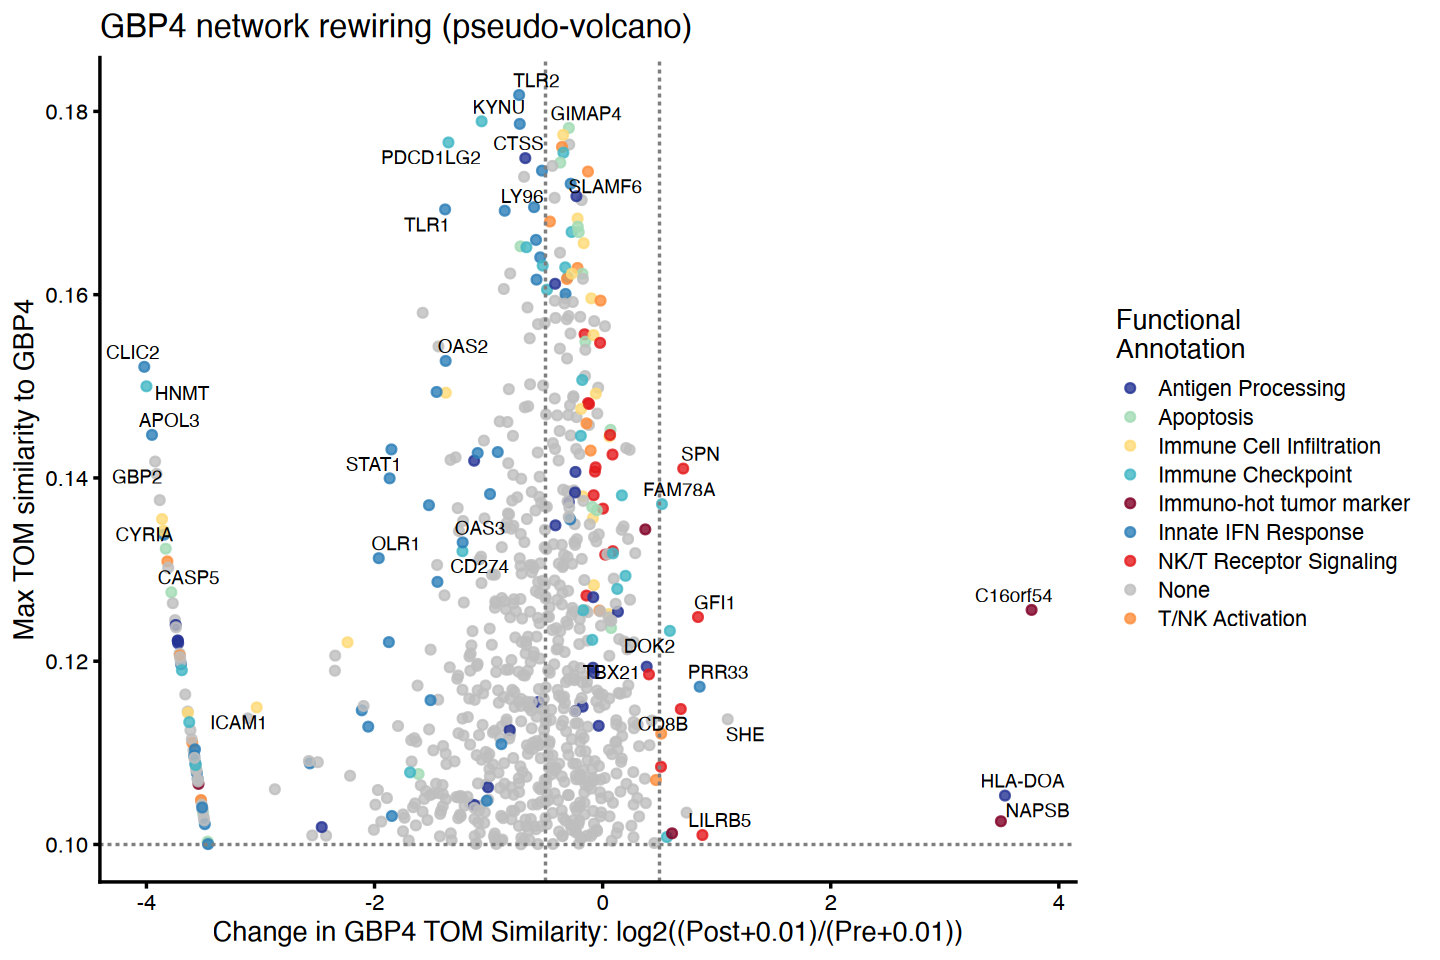

In [220]:
dim(comb_tom)
library(ggplot2)
library(ggrepel)

options(repr.plot.width=12, repr.plot.height=8)

comb_tom$log2FC <- log2((comb_tom$Post+0.01)/(comb_tom$Pre+0.01))
comb_tom$y_strength <- pmax(comb_tom$Pre, comb_tom$Post)

genes_label = c("CLIC2", "HNMT", "APOL3", "GBP2", "PDCD1LG2", "KYNU", "SLAMF6", "C16orf54", "HLA-DOA", "NAPSB", "TLR1", "OAS3", 'OAS2', 'STAT1', 'OLR1', "TLR2", "GIMAP4", "SPN", "SHE", "CD8B", "DOK2", 'GFI1', 'TBX21', 'LILRB5',
'PRR33', 'LY96', 'CYRIA', 'ICAM1', 'CD274', 'CTSS', 'FAM78A', 'DOK2', 'CASP5')

ggplot(comb_tom, aes(x = log2FC, y = y_strength)) +
  geom_point(aes(color = Funct_Annot), alpha = 0.8, size = 2) +
  geom_hline(yintercept = 0.1, linetype = "dashed", color = "grey50") +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "grey50") +
  scale_color_manual(values = colors_use) +
  geom_text_repel(
    data = comb_tom[comb_tom$Gene %in% genes_label,],
	#data = comb_tom[comb_tom$Funct_Annot == "Apoptosis",],
    aes(label = Gene),
    max.overlaps = 15
  ) +
  labs(
    x = "Change in GBP4 TOM Similarity: log2((Post+0.01)/(Pre+0.01))",
    y = "Max TOM similarity to GBP4",
    title = "GBP4 network rewiring (pseudo-volcano)", color="Functional\nAnnotation"
  ) +
  theme_classic(base_size=16)




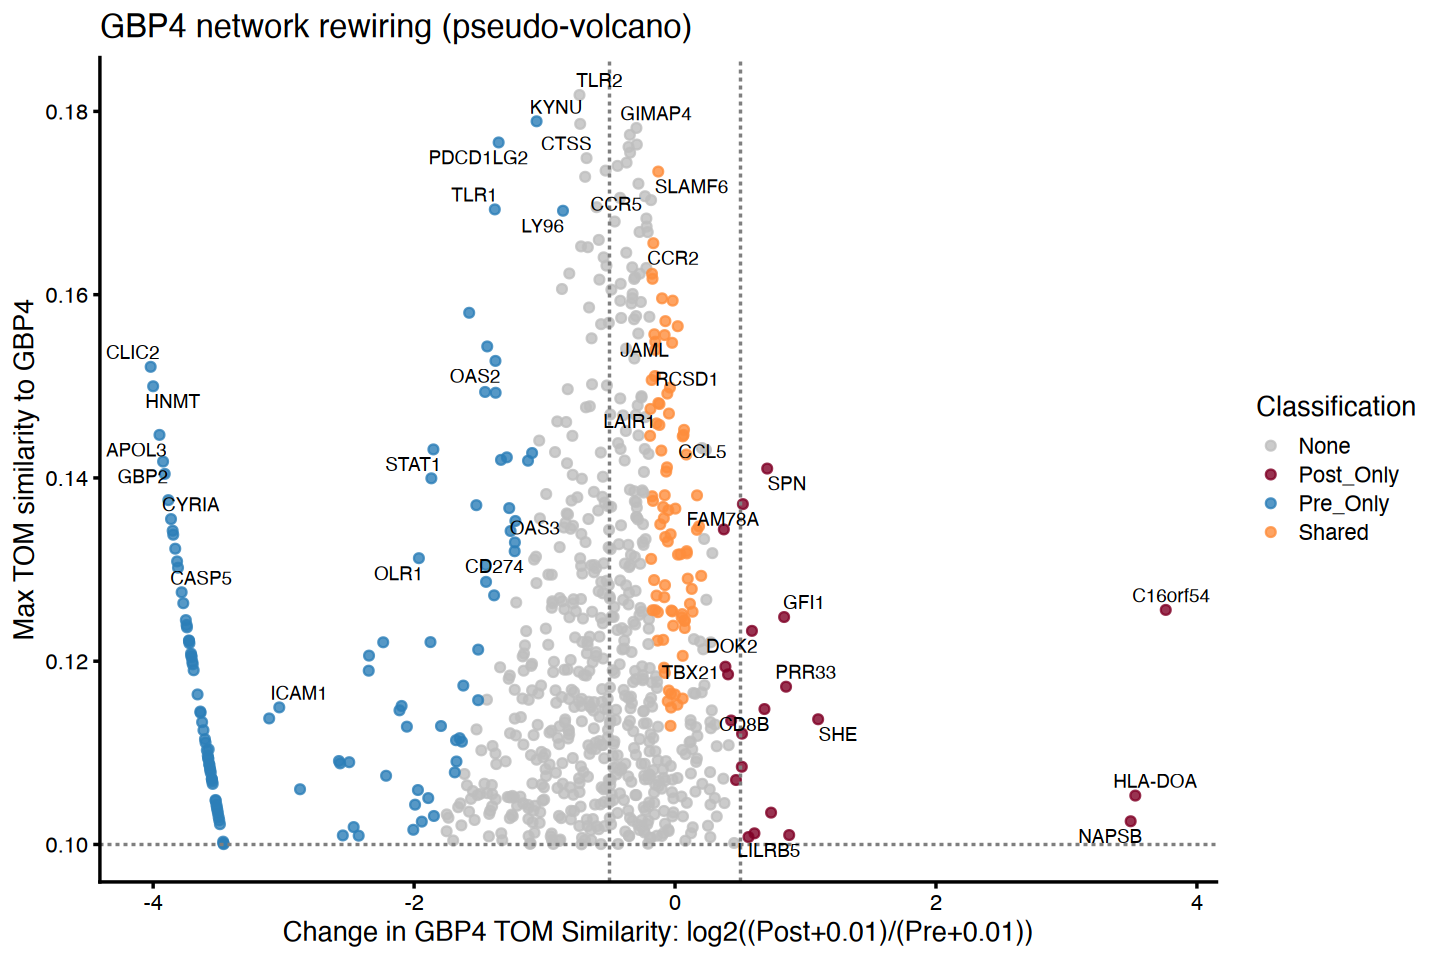

In [230]:
genes_label = c("CLIC2", "HNMT", "APOL3", "GBP2", "PDCD1LG2", "KYNU", "SLAMF6", "C16orf54", "HLA-DOA", "NAPSB", "TLR1", "OAS3", 'OAS2', 'STAT1', 'OLR1', "TLR2", "GIMAP4", "SPN", "SHE", "CD8B", "DOK2", 'GFI1', 'TBX21', 'LILRB5',
'PRR33', 'LY96', 'CYRIA', 'ICAM1', 'CD274', 'CTSS', 'FAM78A', 'DOK2', 'CASP5', 'CCR5', 'CCR2', 'CCL5', 'LAIR1', 'JAML', 'RCSD1')

ggplot(comb_tom, aes(x = log2FC, y = y_strength)) +
  geom_point(aes(color = Label), alpha = 0.8, size = 2) +
  geom_hline(yintercept = 0.1, linetype = "dashed", color = "grey50") +
  geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "grey50") +
  scale_color_manual(values = c("None"="grey", "Shared"="#fd8d3c", "Pre_Only"="#2c7fb8", "Post_Only"="#800026")) +
  geom_text_repel(
    data = comb_tom[comb_tom$Gene %in% genes_label,],
	#data = comb_tom[comb_tom$Funct_Annot == "Apoptosis",],
    aes(label = Gene),
    max.overlaps = 15
  ) +
  labs(
    x = "Change in GBP4 TOM Similarity: log2((Post+0.01)/(Pre+0.01))",
    y = "Max TOM similarity to GBP4",
    title = "GBP4 network rewiring (pseudo-volcano)", color="Classification"
  ) +
  theme_classic(base_size=16)


In [136]:
comb_tom[comb_tom$Gene %in% c("KLRK1", "KLRC4-KLRK1", "SLAMF1", "SPN"),]

,Gene,Post,Pre,Post_Pre,label,Label,Funct_Annot
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
6860,KLRC4-KLRK1,0.1446921,0.13784095,0.006851151,None,Shared,None
6865,KLRK1,0.1425523,0.13366542,0.008886874,None,Shared,Shared_Cytotoxic_Lymph_Markers
20055,SLAMF1,0.1322471,0.14298755,-0.010740453,None,Shared,None
20832,SPN,0.1410218,0.08255001,0.058471742,None,Post_Only,Post_NKTcellactivation
